# Материалы:
* Презентация: (https://disk.yandex.ru/i/NUU-OFU6wTX4Og)

# Задача:
Проанализировать клиентов регионального банка и выделить сегменты клиентов, которые склонны уходить из банка.

<b> Название проекта: </b>Анализ оттока клиентов банка "Метанпром".

<b> Цель проекта: </b>Анализ клиентов регионального банка. Выделение сегментов клиентов, которые склонны уходить из банка. Подготовка рекомендаций для отдела маркетинга.

<b> Задачи проекта:</b><br>
* Проанализировать данные.
* Определить значимые признаки отточности.
* Составить портреты клиентов.
* Сформулировать и проверите статистические гипотезы.
* Объединяя признаки отточности, сформировать сегменты.
* Составить предложения для отдела маркетинга по сегментам.

# План работы:
<b> Шаг 1. Загрузка данных, импорт библиотек.</b><br>

Датасет содержит данные о клиентах банка «Метанпром». Банк располагается в Ярославле и областных городах: Ростов Великий и Рыбинск.

<b>Путь к датасету: </b>https://code.s3.yandex.net/datasets/bank_scrooge.csv

<b>Набор данных:</b>
* userid — идентификатор пользователя,
* score — баллы кредитного скоринга,
* city — город,
* gender — пол,
* age — возраст,
* equity — количество баллов собственности,
* balance — баланс на счёте,
* products — количество продуктов, которыми пользуется клиент,
* credit_card — есть ли кредитная карта,
* last_activity — активный клиент,
* estimated_salary — заработная плата клиента,
* churn — ушёл или нет.

<b> Шаг 2. Предобработка данных:</b><br>
* Проверка корректности типов данных 
* Проверка корректности наименований колонок
* Проверка и редактирование пропусков 
* Проверка наличия явных и не явных дубликатов
* Проверка числовых данных на выбросы (метод describe, построение гистограмм).
* Кодирование данных (создание колонок, для анализа корреляции). 

<b> Шаг 3. Проведение исследовательского анализ данных:</b><br>

* Определить значимые признаки отточности (интервалы значений характеристик, которые связаны с повышенным оттоком).
* Сравнить портреты типичных клиентов, которые склонны к оттоку.<br>
* Корреляционный анализ признака churn с другими признаками.

<b> Шаг 4. Проверка статистических гипотез</b><br>
* Проверка первой гипотезы: Нет значимых различий в средних заработных платах между оставшимися клиентами и ушедшими. 
* Проверка второй гипотезы (пока не прописал). 
* Объяснение методов проведения проверки гипотез.

<b> Шаг 5. Подведение промежуточных итогов по результатам исследовательского анализа данных, корреляционного анализа, проверки гипотез. </b><br>

<b> Шаг 6. Сегментация клиентов. </b><br>

<b> Шаг 7. Приоритизация сегментов (без использования ML).</b><br>

<b> Шаг 8. Подведение итоговых выводов, итоговые рекомендации для отдела маркетинга.</b><br>

## Шаг. Загрузка данных, импорт библиотек.

In [1]:
#Установка библиотеки phi_k
!pip install phik

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as st
import phik

#формат показателей с плавающей точкой:
pd.set_option('display.float_format', '{:,.2f}'.format)

#Снятие ограничений на отображения количества колонок:
pd.set_option('display.max_columns', None) 

#Снятие ограничений на отображения количества колонок:
#pd.set_option('display.max_rows', None) 

sns.set_theme(rc={'figure.figsize':(10,5)})

In [3]:
data = pd.read_csv('https://code.s3.yandex.net/datasets/bank_scrooge.csv')

## Шаг. Предобработка данных.

In [4]:
#Заведем функцию для первичного осмотра:
def first_look(check):
    long = len(check)
    if long < 10:
        print('Вывод таблицы:')
        display(check)
    else:
        print('Вывод первых 5 строк таблицы:')
        display(check.head(5))
        print('Вывод последних 5 строк таблицы:')
        display(check.tail(5))

    print('\nТипы данных:\n')
    check.info()
    print('\nКоличество уникальных значений по колонкам:\n')
    for k in check.columns:
        print(f'{k}: {check[k].nunique()}')
    print('\nСтатистическая сводка:')
    display(check.describe())
    print('\nПропуски:')
    display(check.isna().sum())    
    print(f'\nКоличество полных дубликатов: {check.duplicated().sum()}\n')
    
    check.hist(figsize=(15,20), bins = 20)
    plt.show()

Вывод первых 5 строк таблицы:


,USERID,score,city,gender,age,equity,balance,products,credit_card,last_activity,EST_SALARY,churn
0,183012,850.00,Рыбинск,Ж,25.00,1,"59,214.82",2,0,1,"75,719.14",1
1,146556,861.00,Рыбинск,Ж,37.00,5,"850,594.33",3,1,0,"86,621.77",0
2,120722,892.00,Рыбинск,Ж,30.00,0,NaN,1,1,1,"107,683.34",0
3,225363,866.00,Ярославль,Ж,51.00,5,"1,524,746.26",2,0,1,"174,423.53",1
4,157978,730.00,Ярославль,М,34.00,5,174.00,1,1,0,"67,353.16",1


Вывод последних 5 строк таблицы:


,USERID,score,city,gender,age,equity,balance,products,credit_card,last_activity,EST_SALARY,churn
9995,120553,814.00,Рыбинск,М,27.00,1,"78,144.65",1,0,1,"18,943.64",0
9996,139170,894.00,Ярославль,М,46.00,0,NaN,1,1,0,"196,898.29",0
9997,115639,903.00,Ярославль,М,24.00,0,NaN,2,1,1,"108,905.09",0
9998,148700,777.00,Ярославль,Ж,68.00,3,"865,457.97",3,0,1,"86,874.90",0
9999,96267,828.00,Рыбинск,Ж,58.00,3,"1,180,886.70",4,0,1,"21,422.37",0



Типы данных:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   USERID         10000 non-null  int64  
 1   score          10000 non-null  float64
 2   city           10000 non-null  object 
 3   gender         10000 non-null  object 
 4   age            9974 non-null   float64
 5   equity         10000 non-null  int64  
 6   balance        7705 non-null   float64
 7   products       10000 non-null  int64  
 8   credit_card    10000 non-null  int64  
 9   last_activity  10000 non-null  int64  
 10  EST_SALARY     10000 non-null  float64
 11  churn          10000 non-null  int64  
dtypes: float64(4), int64(6), object(2)
memory usage: 937.6+ KB

Количество уникальных значений по колонкам:

USERID: 9927
score: 348
city: 3
gender: 2
age: 68
equity: 10
balance: 7701
products: 6
credit_card: 2
last_activity: 2
EST_SALARY: 9996
churn: 2

Стати

,USERID,score,age,equity,balance,products,credit_card,last_activity,EST_SALARY,churn
count,"10,000.00","10,000.00","9,974.00","10,000.00","7,705.00","10,000.00","10,000.00","10,000.00","10,000.00","10,000.00"
mean,"171,814.71",848.70,42.73,2.63,"827,794.31",1.87,0.68,0.52,"147,866.89",0.18
std,"33,708.24",65.45,12.18,1.98,"1,980,614.15",0.79,0.47,0.50,"139,388.51",0.39
min,"94,561.00",642.00,18.00,0.00,0.00,0.00,0.00,0.00,"2,546.30",0.00
25%,"142,810.25",802.00,33.00,0.00,"295,554.16",1.00,0.00,0.00,"75,251.90",0.00
50%,"172,728.00",853.00,40.00,3.00,"524,272.20",2.00,1.00,1.00,"119,658.10",0.00
75%,"201,261.75",900.00,51.00,4.00,"980,705.85",2.00,1.00,1.00,"174,500.54",0.00
max,"229,145.00","1,000.00",86.00,9.00,"119,113,552.01",5.00,1.00,1.00,"1,395,064.45",1.00



Пропуски:


USERID              0
score               0
city                0
gender              0
age                26
equity              0
balance          2295
products            0
credit_card         0
last_activity       0
EST_SALARY          0
churn               0
dtype: int64


Количество полных дубликатов: 0



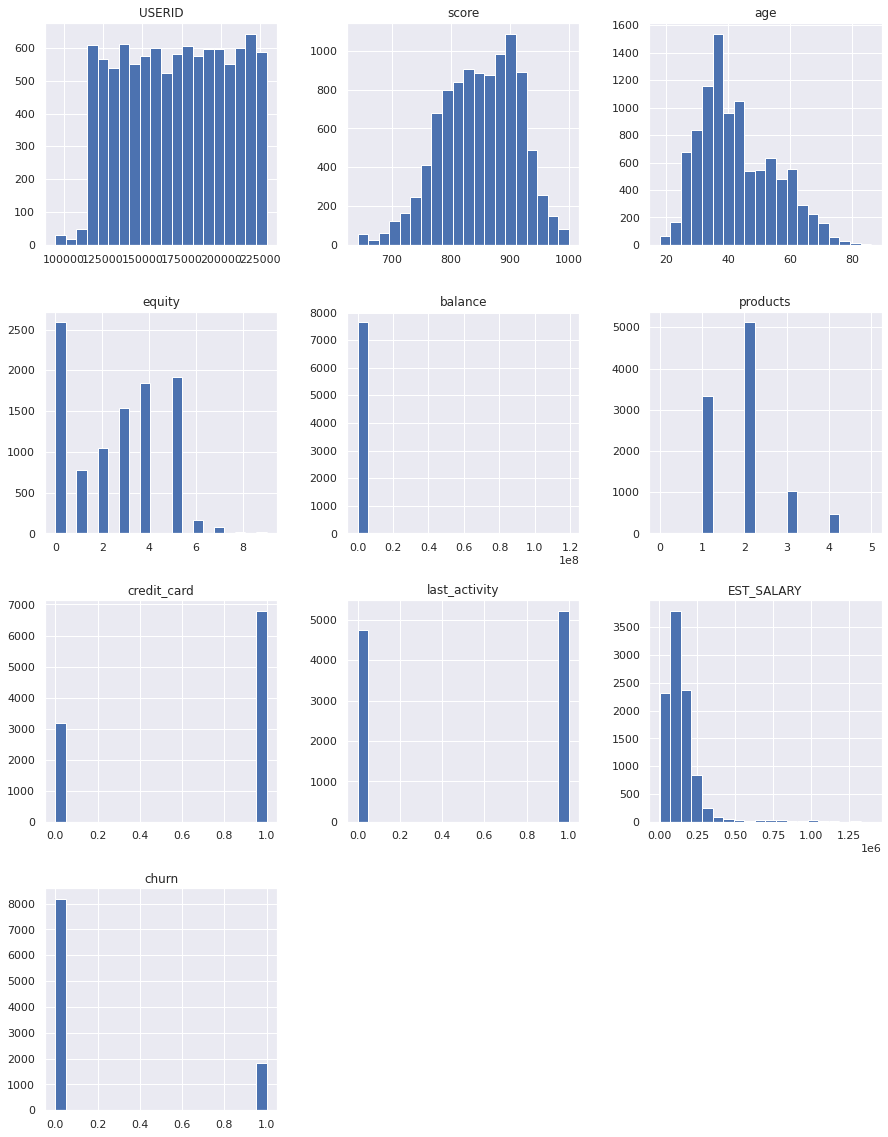

In [5]:
first_look(data)

Первое что бросается в глаза - не корректное наименовение колонок `USERID` и `EST_SALARY`. Переименую с заменой ДФ.

In [6]:
data.rename(columns={'USERID':'user_id', 'EST_SALARY':'est_salary'}, inplace=True)

Проверю наименования колонок.

In [7]:
data.columns

Index(['user_id', 'score', 'city', 'gender', 'age', 'equity', 'balance',
       'products', 'credit_card', 'last_activity', 'est_salary', 'churn'],
      dtype='object')

Займёмся отсутствующими данными в колонках `age` и `balance`.<br> 
Необходимо выяснить природу неприсвоенности данных. Возможные причины:<br> 
1. MCAR (Missing Completely At Random / Отсутствует совершенно случайно) — пропуски не зависят от переменных и не ведут к систематической ошибке (смещение, bias), но увеличивают случайную ошибку (разброс, variance), можно их отбрасывать или заполнять, т.к. заполнение не повлияет на характер связи между заполняемой переменной и остальными;
2. MAR (Missing At Random / Отсутствует случайно) — в рамках каждой из групп, которая есть в описываемой данными совокупности, распределение пропусков случайно, можно их отбрасывать;
3. MNAR (Missing Not At Random / Отсутствует не случайно) — пропуски зависят от данных, без дополнительного обоснования их нельзя отбрасывать или заполнять одним значением, т.к. это приведёт к заметным искажениям.<br> 

Для того чтобы выяснить рассмотрим корреляцию указанных колонок с другими колонками дф (связь). <br> 
Создадим дополнительные колонки со значениями, соответствующими заполненности колонкок.

In [8]:
data['bal_filled'] = data['balance'].isna()
data['age_filled'] = data['age'].isna()

Проверю с помощью библиотеки phik корреляцию колонок `bal_filled` и `age_filled` с другими колонками дф _(пробовал проверить корреляцию методом .corr() - прослеживается обратная зависимость в районе 0.7 у `bal_filled`, у `age_filled` корреляция также не наблюдается)_.

Отдельное спасибо Юре Косульникову за подсказку.

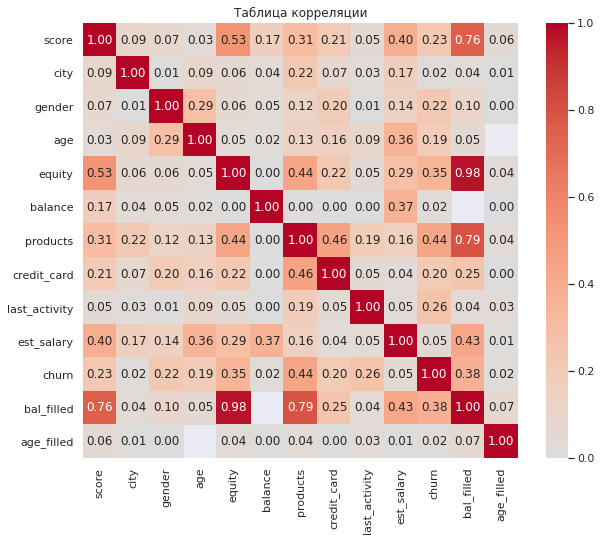

In [9]:
plt.figure(figsize=(10,8))
sns.heatmap(data[['score', 'city', 'gender', 'age', 'equity', 'balance',
       'products', 'credit_card', 'last_activity', 'est_salary', 'churn',
       'bal_filled', 'age_filled']].phik_matrix(bins=10, interval_cols=['score','age', 'balance','est_salary']), 
            center=0,
            annot = True,
            fmt = '.2f',
            cmap='coolwarm',
           square=True)
plt.title('Таблица корреляции')
plt.show()


С колонкой в которой определена заполненность колонка `balance` крайне сильно проявлена корреляция с колонкой `количество баллов собственности`, что является подтверждением того, что пропуски присутствуют не просто так (MNAR подтвержден).
Полагаю, в дальнейшем анализе добавленая колонка участвовать не будет, удалю её. Присваивать заглушку колонке `balance`, видимо не следует, оставлю как есть.<br><br>
Что касается колонки `age`, то у неё нет вообще никакой корреляции с прочими колонками, что подтверждает её не системный характер, количество пустых записей крайне не велико и их влияние на анализ считаю не существенным (MCAR подтвержден). Заполню пустые поля модой.

In [10]:
#Заполним недостающие данные:
data['age'].fillna(data['age'].mode()[0], inplace=True)

В дальнейшей работе колонки `bal_filled` и `age_filled` участвовать не будут. Удалю их из дф.

In [11]:
data.drop(columns=['bal_filled', 'age_filled'], axis=1, inplace=True)

Проверим:

In [12]:
data.head()

,user_id,score,city,gender,age,equity,balance,products,credit_card,last_activity,est_salary,churn
0,183012,850.00,Рыбинск,Ж,25.00,1,"59,214.82",2,0,1,"75,719.14",1
1,146556,861.00,Рыбинск,Ж,37.00,5,"850,594.33",3,1,0,"86,621.77",0
2,120722,892.00,Рыбинск,Ж,30.00,0,NaN,1,1,1,"107,683.34",0
3,225363,866.00,Ярославль,Ж,51.00,5,"1,524,746.26",2,0,1,"174,423.53",1
4,157978,730.00,Ярославль,М,34.00,5,174.00,1,1,0,"67,353.16",1


Проверим колонку `age` на предмет пустых полей.

In [13]:
data['age'].isna().sum()

0

Всё корректно.

Займемся типами данных.<br>


В колонках `score` и `age` только целочисленные значения, при этом тип данных присвоен - с плавающей точкой. Необходимо это поправить.

In [14]:
data[['score','age']] = data[['score','age']].astype(np.int32)

Проверим преобразование.

In [15]:
data[['score','age']].dtypes

score    int32
age      int32
dtype: object

Всё корректно.

Займемся крайне __странными__ показателями.<br>
Согласно describe(), а также гистограмм, в колонках `balance` и `est_salary`, выявлены крайне высокие максимальные показатели. Выведем на экран клиентов банка, у которых на счёте находится больше 10млн.рублей.

In [16]:
data[data['balance']>10000000].sort_values(by='est_salary', ascending=False).reset_index(drop=True)

,user_id,score,city,gender,age,equity,balance,products,credit_card,last_activity,est_salary,churn
0,163640,912,Ярославль,М,35,4,"15,624,095.80",2,0,1,"1,395,064.45",0
1,135243,951,Ярославль,М,38,5,"14,134,432.03",2,1,0,"1,281,547.73",0
2,119793,1000,Ярославль,М,50,5,"12,909,691.02",1,1,0,"1,253,653.40",0
3,221720,1000,Ярославль,Ж,35,5,"21,549,943.63",2,0,0,"1,051,902.65",0
4,201574,983,Ярославль,М,54,3,"11,060,145.42",2,0,1,"1,046,662.18",0
5,203255,999,Ярославль,М,36,4,"10,641,153.66",2,0,0,"1,042,118.22",0
6,227092,1000,Ярославль,М,32,5,"19,757,180.85",2,1,1,"1,024,626.50",0
7,163663,970,Ярославль,М,35,3,"15,004,496.45",2,0,1,"991,012.77",1
8,223516,960,Ярославль,Ж,45,5,"11,331,203.80",2,0,1,"960,435.49",1
9,137434,1000,Ярославль,М,37,4,"20,906,155.51",2,1,1,"947,606.60",1


Интересно: я думал, что люди с максимальным количеством денег не счетах, будут возглавлять список по размеру заработной платы, а они его закрывают... В целом, это ничего не дало, но навело на дополнительные мысли, что главное не размер зарплаты, а умение накапливать и что такое встречается крайне редко. Править нечего. Оставляем.

Также в колонке `products` присутствуют записи, которым присвоено значение `0`. Полагаю, это ошибка, так как врядли может такое быть, что человек является клиентом банка, но не пользуется ни 1 его продуктом. Проверим.

In [17]:
data[data['products']==0]

,user_id,score,city,gender,age,equity,balance,products,credit_card,last_activity,est_salary,churn
8957,147837,962,Рыбинск,Ж,79,3,NaN,0,0,0,"25,063.96",1


Пользователь всего 1 и довольно таки сомнительный. Я даже не знаю что меня смущает больше:
1. возраст - 79 лет. Есть высокая вероятность, что по естественным причинам больше не является клиентом (искренне надеюсь, что это не так. Работаю не с людьми, а с цифрами).
2. баланс - не заполнен. В нем присвоенная мной заглушка (полагаю, средства на счету присутствовали бы хоть какие-то). 
3. "прочие активности" - 0.
4. отток - 1.

Полагаю, это пенсионный счёт некой старушки, куда начислялась пенсия в размере 25063.96 рублей ежемесячно. <br>
Считаю, что уместно следующее (одно из двух):
1. убрать запись из дф.
2. присвоить записи в колонку `products` 1, чтобы в дальнейшем этот 0 нигде не всплывал.

Предпочту второй вариант.

In [18]:
data['products'].replace(0,1, inplace=True)

Проверим.

In [19]:
x = data['products'].value_counts()
print(x)
print()
print('всего записей:',sum(x))

2    5126
1    3342
3    1039
4     474
5      19
Name: products, dtype: int64

всего записей: 10000


Всё верно. нуля нет, количество записей не поменялось. Хотя с другой стороны:

In [20]:
data[data['user_id']==147837]

,user_id,score,city,gender,age,equity,balance,products,credit_card,last_activity,est_salary,churn
8957,147837,962,Рыбинск,Ж,79,3,NaN,1,0,0,"25,063.96",1


Присвоена единица

Проверка на явные дубликаты показала их отсутствие, при этом в колонке `user_id` в 10000 записей находится только 9926 уникальных id, что говорит о дублях (также, это проговаривалось ранее). Рассмотрим задублированные записи.

In [21]:
d_users = data[data.duplicated(subset='user_id', keep=False)==True].sort_values(by='user_id')
d_users

,user_id,score,city,gender,age,equity,balance,products,credit_card,last_activity,est_salary,churn
1893,116540,883,Рыбинск,Ж,55,1,"362,756.49",3,0,1,"175,920.48",1
7694,116540,887,Ярославль,Ж,38,0,NaN,1,0,1,"119,247.61",0
7542,117943,880,Ярославль,Ж,40,0,NaN,1,1,0,"137,718.93",0
4866,117943,855,Рыбинск,Ж,32,6,"1,036,832.93",4,1,1,"107,792.71",1
5896,120258,905,Ярославль,М,30,0,NaN,1,1,1,"146,427.96",0
...,...,...,...,...,...,...,...,...,...,...,...,...
2597,226719,990,Ярославль,М,37,4,"14,648,692.14",2,0,0,"934,412.61",1
8205,227795,840,Рыбинск,М,34,2,"350,768.03",1,1,0,"102,036.14",1
8497,227795,839,Ярославль,М,34,2,"326,593.14",2,1,0,"103,314.92",0
6457,228075,839,Рыбинск,М,39,5,"507,199.85",3,0,1,"85,195.80",0


Судя по записям, можно отметить, что по `user_id` действительно есть совпадения, при этом также совпадает и пол, но не факт, что везде, а город в принципе не совпадает. Проверим на предмет количества записей при проверке не только на `user_id`, но и полу (`gender`), а также городу (`city`).

In [22]:
d_users_gender = data[data.duplicated(subset=['user_id', 'gender'], keep=False)==True].sort_values(by='user_id')

In [23]:
d_users_city = data[data.duplicated(subset=['user_id', 'city'], keep=False)==True].sort_values(by='user_id')

Добавим немножко цифр, чтобы понять откуда могли взяться дубли.

In [24]:
print(f'Количество задублированных записей только по колонке user_id - {len(d_users)}.')
print(f'Количество задублированных записей по колонкам user_id и gender - {len(d_users_gender)}.')
print(f'Количество задублированных записей по колонкам user_id и city - {len(d_users_city)}.\n')
print(f'Доля задублированных записей по колонкам user_id и gender от общего числа \
задублированных по user_id записей составила {len(d_users_gender)/len(d_users):.1%}')

Количество задублированных записей только по колонке user_id - 146.
Количество задублированных записей по колонкам user_id и gender - 82.
Количество задублированных записей по колонкам user_id и city - 0.

Доля задублированных записей по колонкам user_id и gender от общего числа задублированных по user_id записей составила 56.2%


__Предположение:__ Количество записей в выборках не совпадает, при этом в последней выборке с дополнительной проверкой по городам дубли отсутсвуют вовсе, из этого можно сделать несколько выводов:
* Чуть больше чем в половине случаев пол у пользователей совпал, из чего можно сделать вывод, что в противных почти 44% не совпал _(распределение близко к 50/50),_ следовательно это действительно совпадение. 
* Так как по городам дублей не обнаружено, полагаю что в этом и кроется причина - совмещение баз нескольких филиалов в единый датафрейм. В каждом филиале были собственные уникальные записи, которые между собой ничего общего не имеют.

Из вышесказанного можно сделать __вывод__, что это не дубли вовсе, а результат объединения двух неинтегрированных в общую систему баз. 

Добавим кодирование колонок `gender` и `city`, предварительно создав их копии (что в первый раз я благополучно не сделал, пропустил).

In [25]:
# Создание копии колонок:
data[['gender2','city2']]=data[['gender','city']]

# "Кодирование" колонок:
df = pd.get_dummies(data, columns=['gender2','city2']).rename(columns={
    'gender2_Ж':'female',
    'gender2_М':'male',
    'city2_Ростов':'Ростов',
    'city2_Рыбинск':'Рыбинск',
    'city2_Ярославль':'Ярославль'
        }).sort_values(by='churn',ascending=False)
df

,user_id,score,city,gender,age,equity,balance,products,credit_card,last_activity,est_salary,churn,female,male,Ростов,Рыбинск,Ярославль
0,183012,850,Рыбинск,Ж,25,1,"59,214.82",2,0,1,"75,719.14",1,1,0,0,1,0
4229,162361,874,Ярославль,Ж,46,5,"1,033,456.73",2,1,1,"259,161.62",1,1,0,0,0,1
6499,224019,936,Ярославль,М,31,5,"2,931,344.63",2,0,1,"1,108,269.91",1,0,1,0,0,1
1856,116676,849,Ярославль,Ж,27,3,"153,037.03",2,0,1,"62,453.95",1,1,0,0,0,1
1857,119889,787,Рыбинск,Ж,62,5,"547,176.06",2,1,0,"34,893.02",1,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3642,223574,794,Рыбинск,Ж,35,2,"398,176.77",2,1,1,"117,308.35",0,1,0,0,1,0
3641,139393,739,Ярославль,Ж,59,0,NaN,1,1,0,"80,195.95",0,1,0,0,0,1
3640,172758,764,Рыбинск,Ж,44,4,"1,387,722.77",2,0,1,"88,541.96",0,1,0,0,1,0
3639,135969,812,Ярославль,М,43,2,"1,090,732.82",1,1,1,"204,568.35",0,0,1,0,0,1


__Вывод:__ 
1. В датафрейме 10000 записей - достаточно для провеления анализа.
2. Присутствовали некорректные наименования колонок `user_id` и `est_salary`, переименовал.
3. Проверил отсутствующие записи в колонках `age` и `balance`.
4. Типы данных в колонках `age` и `score` привёл к типу `int32`. Также, `gender` и `city` можно было бы присвоить тип `category` для уменьшение веса дф (сейчас не актуально, к тому же, добавляет трудности при построении графиков. Править не буду).
5. Судя по результатам метода discribe(), а также построенных гистограмм, получается, что имеют место быть аномально высокие значения в колонке `balance` (почти 120 млн., полагаю рублей), которое не позволяет корректно отобразить гистограмму по колонке (править не стану, но в дальнейшей визуализации, если потребуется, буду отфильтровывать крайне высокие показатели), а также `est_salary`, но тут уже не так критично. Также, 0 в колонке `products` тоже вызываел сомнение, заменил на 1 в единственной записи.
6. Была проведена проверка на явные и не явные дубли - не обнаружены.
7. Были созданы дополнительные колонки с признаками полов и городами (произведена кодировка). 

## Шаг. Проведение исследовательского анализ данных:</b><br>

* Определить значимые признаки отточности (интервалы значений характеристик, которые связаны с повышенным оттоком).
* Сравнить портреты типичных клиентов, которые склонны к оттоку.<br>
* Корреляционный анализ признака churn с другими признаками.

__Анализ распределения.__ <br>
Рассмотрим по каждой колонке в каких интервалах значений доля ушедших пользователей выше _(кроме user_id)_.
Создадим несколько списков с наименованиями колонок, к которым будут применяться различные методы построения графиков, а также методы расчёта.


In [26]:
# Непрерывные:
continuous_list = ['score','age', 'balance','est_salary'] 

#Категориальные (качественные):
category_list = ['credit_card', 'last_activity', 'female', 'male', 'Ростов', 'Рыбинск', 'Ярославль']

#Дискретные (целочисленные).
discrete_list =  ['products','equity']

#Заведем словарь с названиями на русском для отображения на графиках, а также ограничениями по оси 'x' для построения графиков.
columns_dict = {
    #колонка, наименование на русском, единицы, xmin, xmax, шаг на графике
    'score':['Баллы кредитного скоринга', 'пунктов' ,620, 1000, 10],
    'city':['Город'],
    'gender':['Пол'],
    'age':['Возраст', 'лет', 16, 90, 1],
    'equity':['Количество баллов собственности'],
    'balance':['Баланс на счёте','млн.руб.', 0, 5000000, 100000],
    'products':['Количество продуктов, которыми пользуется клиент'],
    'credit_card':['Наличие кредитной карты'],
    'last_activity':['Активный клиент'],
    'est_salary':['Заработная плата', 'руб.', 0, 500000, 10000],
    'churn':['Признак оттока'],
    'female':['Среди женщин'], 
    'male':['Среди мужчин'],
    'Ростов':['По Ростову'],
    'Рыбинск':['По Рыбинску'], 
    'Ярославль':['По Ярославлю']
}

Построим графики по `непрерывным переменным`. При этом, из-за довольно крупных всплесков, ограничим исследуемую область на оси `x`, а также, отсечём "заглушку" в колонке `balance` (-1), которая слишком сильно дезинформирует график.

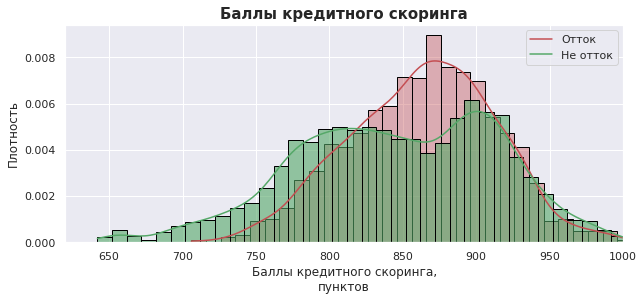

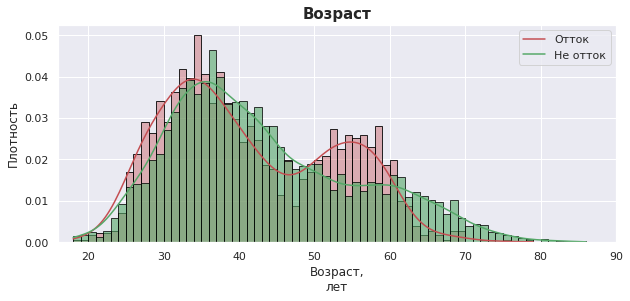

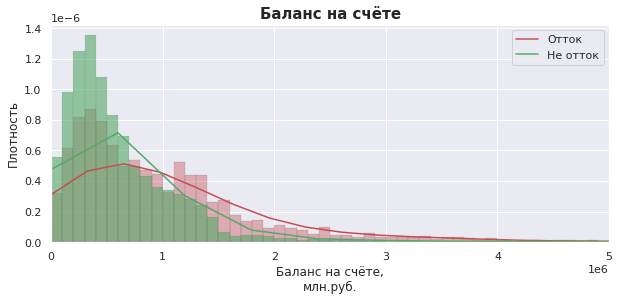

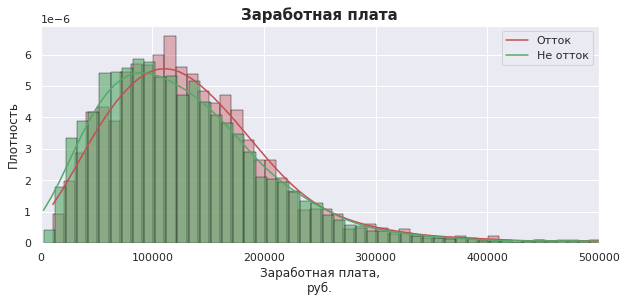

In [27]:
mean_churn=df['churn'].mean()
for column in continuous_list:
    plt.figure(figsize=(10,4))
    ax = sns.histplot(data=df[(df[column]>=0)& (df['churn']==1)], x=column, edgecolor='black', common_norm=False, stat="density", color='r', alpha=0.4, kde=True, binwidth=columns_dict.get(column)[4])
    ax = sns.histplot(data=df[(df[column]>=0)& (df['churn']==0)], x=column, edgecolor='black', common_norm=False, stat="density", color='g', alpha=0.6, kde=True, binwidth=columns_dict.get(column)[4])
    plt.xlabel(f'{columns_dict.get(column)[0]},\n{columns_dict.get(column)[1]}')
    ax.set_xlim(columns_dict.get(column)[2], columns_dict.get(column)[3])
    plt.title(columns_dict.get(column)[0], fontsize = 15, weight='bold')
    
    plt.legend(['Отток','Не отток'])
    plt.ylabel('Плотность')
   

Из графиков по `непрерывным переменным` можно выделить следующие интервалы, на которых плотность оттока превышала плотность оставшихся клиентов:
1. _Баллы кредитного скорринга_ - примерно с 830 до 930
2. _Возраст_ - 2 интервала: примерно с 25 до 35 лет, с 51 до 61 года.
3. _Баланс на счёте_ - при балансе счета примерно от 800 тыс. руб. на счёте.
4. _Заработная плата_ - в интервале от 100 тыс. руб. до 210 тыс. руб. примерно. 


Построим графики по `Категориальным переменным`.

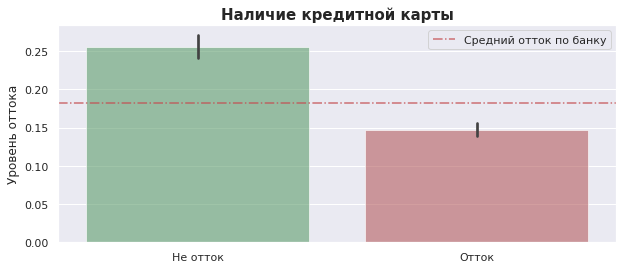

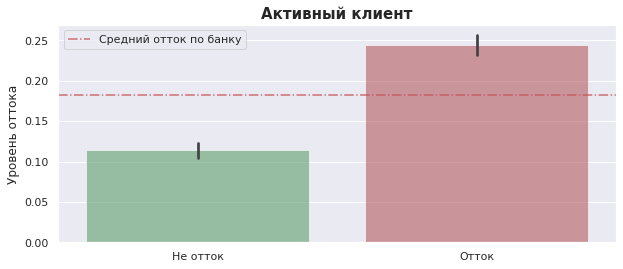

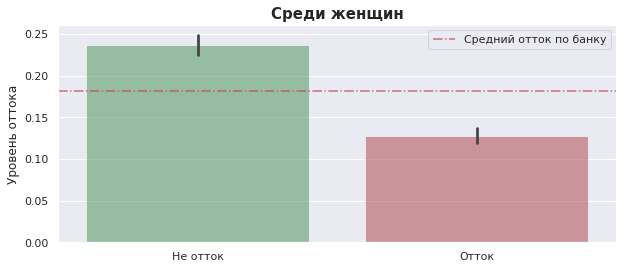

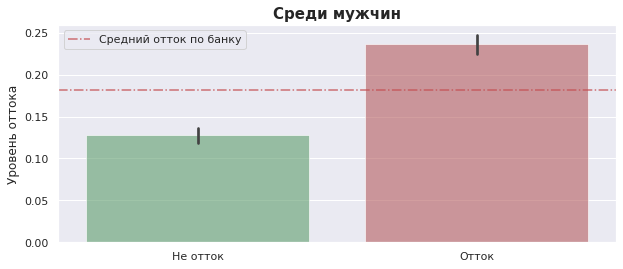

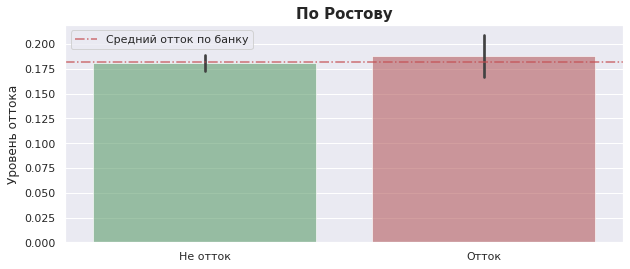

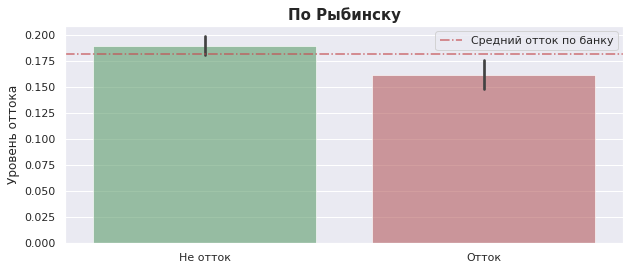

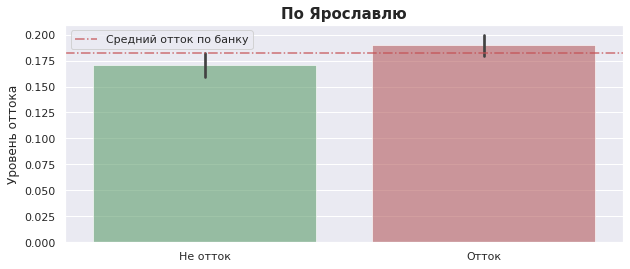

In [28]:
for column in category_list:
    plt.figure(figsize=(10,4))
    col_churn=df.groupby(column)['churn'].mean()
    plt.title(columns_dict.get(column)[0], fontsize=15, weight='bold')
    ax = sns.barplot(data = df, x=column, y='churn', palette=['g','r'], alpha=0.6)
    ax.axhline(y=mean_churn, color='r', ls='-.', alpha=0.8, label=f'Средний отток по банку')
    ax.set_xlabel('')
    ax.set_ylabel('Уровень оттока')
    ax.set_xticklabels(['Не отток','Отток'])
    plt.legend() 


По `категориальным переменным` можно сделать следующие выводы:
1. _Пользователи кредитных карт_ реже склонны к оттоку, чем те, кто ими не пользуются.
2. _Активные клиенты_ чаще склонны к оттоку.
3. _Женщины_ значительно реже склонны к оттоку, чем _мужчины_.
4. _Клиенты банка в Ярославле и Ростеве_ не значительно выше среднего склонны к оттоку, в _Рыбинске_ - чуть ниже.

Построим графики по `дискретным переменным`.

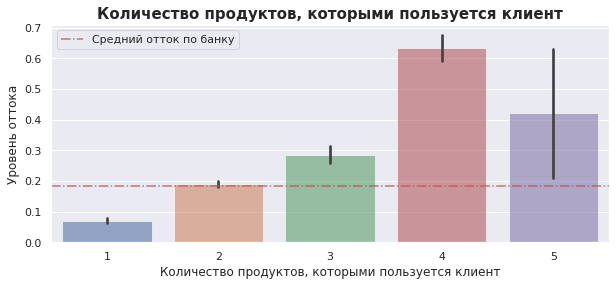

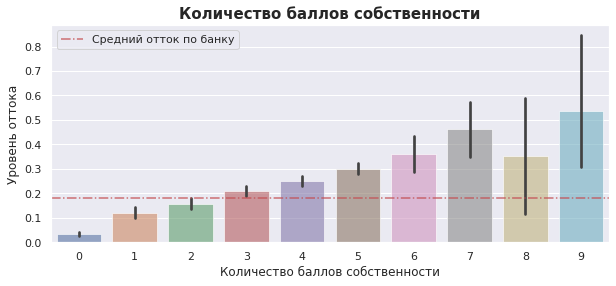

In [29]:
for column in discrete_list:
    plt.figure(figsize=(10,4))
    col_churn=df.groupby(column)['churn'].mean()
    plt.title(columns_dict.get(column)[0], fontsize=15, weight='bold')
    ax = sns.barplot(data = df, x=column, y='churn', alpha=0.6)
    ax.axhline(y=mean_churn, color='r', ls='-.', alpha=0.8, label='Средний отток по банку')
    ax.set_xlabel(columns_dict.get(column)[0])
    ax.set_ylabel('Уровень оттока')
    plt.legend()

По `дискретным переменным` можно сделать следующие выводы:
1. _Количество продуктов, которыми пользуется клиент_ - чем больше продуктов использует, тем выше вероятность оттока. От 3х продуктов наблюдается преобладание ушедших пользователей.
2. _Количество баллов собственности_ - чем выше количество баллов собственности, тем выше вероятность оттока. От 3х баллов оценки собственности, наблюдаеься преобладание ушедших пользователей.

__Корреляция__:<br> Выведем таблицу корреляции, рассчитанную методом phik_matrix() из библиотеки phik по дф, но без колонок, которые не имеют отношения к статистике (`user_id`), а также те, по которым были созданы категориальные колонки (`city`, `gender`), первой колонкой в таблице выведем `churn`.

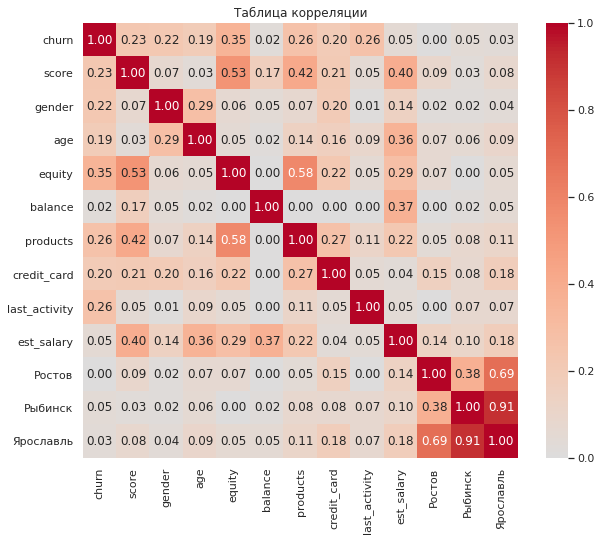

In [30]:
plt.figure(figsize=(10,8))
sns.heatmap(df[['churn', 'score', 'gender', 'age', 'equity', 'balance',
       'products', 'credit_card', 'last_activity', 'est_salary',
       'Ростов', 'Рыбинск', 'Ярославль']].phik_matrix(
        interval_cols=continuous_list, 
        bins=10), #поигрался с количеством корзин, ничего не дало. Изменения крайне не значительные. 
            center=0,
            annot = True,
            fmt = '.2f',
            cmap='coolwarm',
           square=True)
plt.title('Таблица корреляции')
plt.show()

Выведем отдельно график с коэффициентами корреляции для колонки оттока по другим колонкам (кроме `id`):

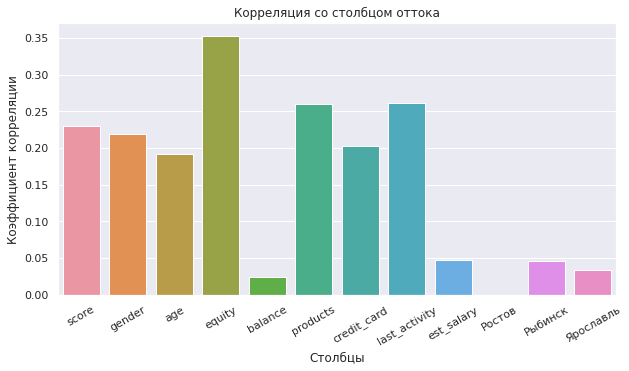

In [31]:
#Создадим матрицу с коэффициентами корреляции:
matrix = df[['churn', 'score', 'gender', 'age', 'equity', 'balance','products', 'credit_card', 'last_activity', 'est_salary',
       'Ростов', 'Рыбинск', 'Ярославль']].phik_matrix(interval_cols=continuous_list, bins=10)

#Сделаем срез матрицы по которому будем строить график:
m_slice = matrix.iloc[1:, 0]

#Выведем график, который будет содержать только коэффициенты корреляции для колонки оттока. 
labels = m_slice.index
ax = sns.barplot(x=labels, y=m_slice)
ax.set_title('Корреляция со столбцом оттока')
ax.set_xlabel('Столбцы')
ax.set_ylabel('Коэффициент корреляции')
ax.set_xticklabels(labels, rotation=30)
plt.show()


In [32]:
# Соберем для визуализации таблицу Чеббока:
data = {'Cила связи':['Слабая', 'Умеренная', 'Заметная', 'Высокая', 'Весьма высокая'], 
        'Теснота связи':['0.1-0.3', '0.3-0.5', '0.5-0.7', '0.7-0.9', '0.9-1.0']}
Cheddok = pd.DataFrame(data=data)
display(Cheddok)

,Cила связи,Теснота связи
0,Слабая,0.1-0.3
1,Умеренная,0.3-0.5
2,Заметная,0.5-0.7
3,Высокая,0.7-0.9
4,Весьма высокая,0.9-1.0


В целом, колонка оттока имеет умеренную корреляцию с колонкой `количество баллов собственности` - 0.35, а также слабую корреляцию с колонками: 
`баллы кредитного скоринга` - 0.23, 
`возраст` - 0.19, 
`количество продуктов, которыми пользуется клиент` - 0.26, 
`наличие кредитной карты` - 0.2, 
`активный клиент` - 0.26, 
`пол` - 0.22.   

Рассмотрим меры центральной тенденции по каждому показателю.

In [33]:
gr_cont = df.groupby(by='churn')[continuous_list].agg('mean').rename(columns={'score':'баллам кредитного скоринга','age':'возрасту','balance':'балансу на счёте', 'est_salary':'заработной плате'}).add_prefix('Среднее по ').sort_index(ascending=False).T.rename(columns={0:'Не отток', 1:'Отток'})
gr_cont['Относительная разница, %'] = (gr_cont['Отток'] - gr_cont['Не отток']) / gr_cont['Не отток']*100
gr_cate = df.groupby(by='churn')[category_list].agg(lambda x: st.mode(x, keepdims=True)[0][0]).rename(columns={'credit_card':'наличию кредитной карты','last_activity':'активным пользователям','female':'женщинам', 'male':'мужчинам', 'Ростов':'Ростову', 'Рыбинск':'Рыбинску', 'Ярославль':'Ярославлю'}).add_prefix('Мода по ').sort_index(ascending=False).T.rename(columns={0:'Не отток', 1:'Отток'})
gr_cate['Относительная разница, %'] = '-'
gr_disc = df.groupby(by='churn')[discrete_list].agg('median').rename(columns={'products':'количеству продуктов','equity':'количеству баллов собственности'}).add_prefix('Медиана по ').sort_index(ascending=False).T.rename(columns={0:'Не отток', 1:'Отток'})
gr_disc['Относительная разница, %'] = '-'
gr_tot = pd.concat([gr_cont, gr_disc, gr_cate])
gr_tot

churn,Отток,Не отток,"Относительная разница, %"
Среднее по баллам кредитного скоринга,863.40,845.43,2.13
Среднее по возрасту,41.45,43.00,-3.61
Среднее по балансу на счёте,"1,133,993.27","733,982.59",54.50
Среднее по заработной плате,"148,243.01","147,783.20",0.31
Медиана по количеству продуктов,2.00,2.00,-
Медиана по количеству баллов собственности,4.00,3.00,-
Мода по наличию кредитной карты,1.00,1.00,-
Мода по активным пользователям,1.00,0.00,-
Мода по женщинам,0.00,1.00,-
Мода по мужчинам,1.00,0.00,-


__Выводы:__<br>
В целом, по графикам можно выделить, что основными характеристиками, влияющими на отток являются:
1. _Баллы кредитного скорринга_ - примерно с 830 до 930
2. _Возраст_ - 2 интервала: примерно с 25 до 35 лет, с 51 до 61 года.
3. _Баланс на счёте_ - при балансе счета примерно от 800 тыс. руб. на счёте.
4. _Заработная плата_ - в интервале от 100 тыс. руб. до 210 тыс. руб. примерно. 
5. _Пользователи кредитных карт_ реже склонны к оттоку, чем те, кто ими не пользуются.
6. _Активные клиенты_ чаще склонны к оттоку.
7. _Женщины_ значительно реже склонны к оттоку, чем _мужчины_.
8. _Клиенты банков в Ярославле и Ростеве_ не значительно выше среднего склонны к оттоку, в _Рыбинске_ - чуть ниже.
9. _Количество продуктов, которыми пользуется клиент_ - чем больше продуктов использует, тем выше вероятность оттока. От 3х продуктов наблюдается преобладание ушедших пользователей.
10. _Количество баллов собственности_ - чем выше количество баллов собственности, тем выше вероятность оттока. От 3х баллов оценки собственности, наблюдаеься преобладание ушедших пользователей.

Судя по таблице корреляции, следующие показатели имели наибольшую связь:
1. умеренную:
    * `количество баллов собственности` - 0.35.
2. слабую: 
    * `баллы кредитного скоринга` - 0.23, 
    * `возраст` - 0.19, 
    * `количество продуктов, которыми пользуется клиент` - 0.26, 
    * `наличие кредитной карты` - 0.2, 
    * `активный клиент` - 0.26, 
    * `пол` - 0.22.  
    
По мерам центральной тенденции:<br>
сильная разница у колонок: 
* `баланс на счёте` - отток при средней относительной разнице больше чем в 2 раза.
* `количество баллов собственности` - отток при 4 баллах (медиана).
* `женщины` не склонны к оттоку по моде.
* `мужчины` склонны к оттоку по моде.<br>

Прочие меры центральной тенденции особо не различаются.

## Шаг. Проверка статистических гипотез.

__Сформируем первую гипотезу__: Нет значимых различий в средних заработных платах между оставшимися клиентами и ушедшими.<br><br>
_Нулевая гипотеза:_ различия в средних заработных платах между оставшимися клиентами и ушедшими не значительны.<br>
_Альтернативная гипотеза:_ различия в средних заработных платах между оставшимися клиентами и ушедшими весьма значительны.

Имеет смысл для проверки гипотезы применить t-test_ind, но перед этим следует проверить несколько моментов:
- независимость выборок;
- нормальность распределения;
- равенство дисперсий (в случае неравенства дисперсий или разнице в размере выборок более чем на 25% используется поправка Уэлча через настройку equal_var=False;
- отсутствие явных выбросов, которые будут влиять на расчёт среднего.

Создадим 2 независимые выборки с разбиением по колонке оттока, а также сравним их размеры:
* только отточных клиентов (`churn` = 1)
* не отточных клиентов (`churn` = 0)

In [34]:
churned_df = df[df['churn']==1]
unchurned_df = df[df['churn']==0]
print(f'Размер дф с отточными клиентами составляет {len(churned_df)} записей')
print(f'Размер дф с не отточными клиентами составляет {len(unchurned_df)} записей')
print(f'Разница между размерами дф составляет {len(unchurned_df)/len(churned_df):.1f} раз')

Размер дф с отточными клиентами составляет 1820 записей
Размер дф с не отточными клиентами составляет 8180 записей
Разница между размерами дф составляет 4.5 раз


Рассмотрим всплески:

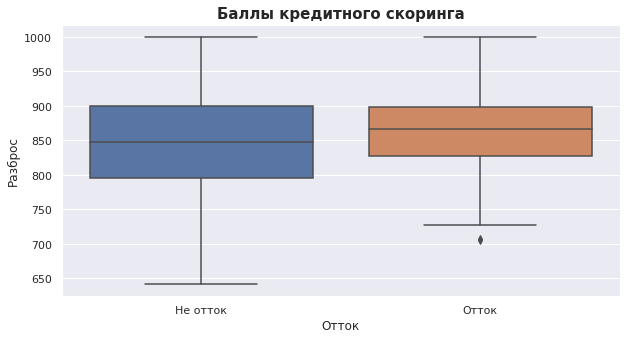

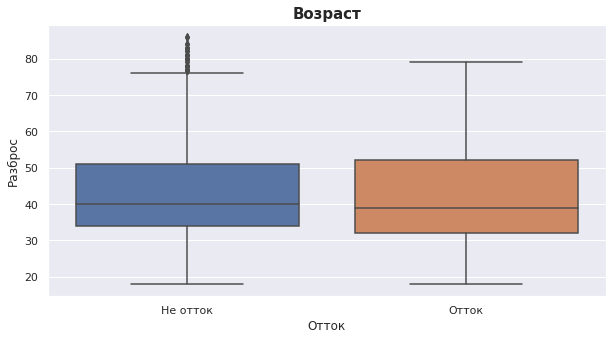

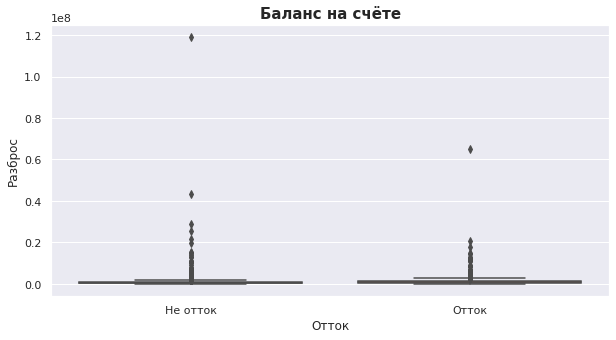

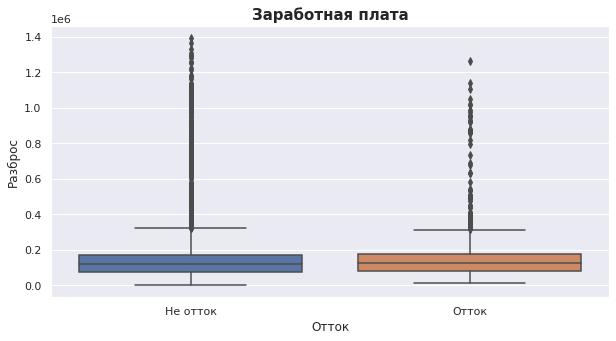

In [35]:
for column in continuous_list:
    ax=sns.boxplot(data=df, x='churn', y=column)
    ax.set_title(columns_dict.get(column)[0], weight='bold', fontsize=15)
    ax.set_ylabel('Разброс')
    ax.set_xlabel('Отток')
    ax.set_xticklabels(['Не отток','Отток'])
    plt.show()

Присутствуют явные выбросы, которые могут влиять на результат проверки гипотез. Полагаю, в случае проверок гипотез по значениям в колонках `Баланс на счёте` и `Заработная плата`, имеет смысл устанавливать верхную границу.

Рассмотрим дисперсии по колонке `Заработная плата` (проверим равенство по выборкам), при этом возьмем не все значения, а где `Заработная плата` меньше или равна 400 000 рублей. <br>
Также, посмотрим на сколько сильно изменятся размеры выборок. <br> 
Проверим равенство дисперсий:

In [36]:
unch_sal = df[(df['churn']==0)&(df['est_salary']<=400000)]
ch_sal = df[(df['churn']==1)&(df['est_salary']<=400000)]

print(f'Количество записей после фильтрации всплесков уменьшилось по неотточным клиентам на \
{1-len(unch_sal)/len(unchurned_df):.1%}, составило {len(unch_sal)} записей.')
print(f'Количество записей после фильтрации всплесков уменьшилось по отточным клиентам на \
{1-len(ch_sal)/len(churned_df):.1%}, составило {len(ch_sal)} записей.\n')

print(f"Дисперсия по выборке не отточных составила {np.var(unch_sal['est_salary']):.1f}")
print(f"Дисперсия по выборке отточных составила {np.var(ch_sal['est_salary']):.1f}")


Количество записей после фильтрации всплесков уменьшилось по неотточным клиентам на 3.5%, составило 7893 записей.
Количество записей после фильтрации всплесков уменьшилось по отточным клиентам на 2.7%, составило 1770 записей.

Дисперсия по выборке не отточных составила 5010412283.9
Дисперсия по выборке отточных составила 4715802595.3


Сокращение записей не значительно, дисперсии не равны. 
Применим двусторонний t-test с поправкой Уэлча через настройку `equal_var=False`, критический уровень статистической значимости используем 0.05.

In [37]:
alpha = 0.05

results = st.ttest_ind(ch_sal['est_salary'],
                       unch_sal['est_salary'],
                       equal_var=False,
                       alternative='two-sided')

print(f'p-value: {results.pvalue:0.5f}')

if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не удалось отвергнуть нулевую гипотезу')

p-value: 0.00021
Отвергаем нулевую гипотезу


__Результат:__ <br>
Различия в средних заработных платах между оставшимися клиентами и ушедшими весьма значительны.

__Сформируем вторую гипотезу__: Нет значимых различий в количестве продуктов, которыми пользуются оставшиеся и ушедшие клиенты.<br><br>
_Нулевая гипотеза:_ различие в количестве продуктов, которыми пользуются оставшиеся и ушедшие клиенты не значительно.<br>
_Альтернативная гипотеза:_ различие в количестве продуктов, которыми пользуются оставшиеся и ушедшие клиенты весьма значительны.

При проведении теста используем аналогичные настройки первому тесту, т.к. условия не менялись (условно).

In [38]:
alpha = 0.05

results = st.ttest_ind(ch_sal['products'],
                       unch_sal['products'],
                       equal_var=False,
                       alternative='two-sided')

print(f'p-value: {results.pvalue}')

if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не удалось отвергнуть нулевую гипотезу')

p-value: 7.457171328774006e-131
Отвергаем нулевую гипотезу


__Результат:__ <br>
Различие в количестве продуктов, которыми пользуются оставшиеся и ушедшие клиенты весьма значительны.

__Выводы:__<br>
В шаге 4 были сформированы 2 гипотезы, результаты проведенных тестов по которым следующие:
1. Различия в средних заработных платах между оставшимися клиентами и ушедшими весьма значительны - нулевая гипотеза отвергнута.
2. Различие в количестве продуктов, которыми пользуются оставшиеся и ушедшие клиенты весьма значительны - нулевая гипотеза отвергнута.

## Шаг. Подведение промежуточных итогов по результатам исследовательского анализа данных, корреляционного анализа, проверки гипотез.

В целом, по графикам можно выделить, что основными характеристиками, влияющими на отток являются:
1. _Баллы кредитного скорринга_ - примерно с 830 до 930
2. _Возраст_ - 2 интервала: примерно с 25 до 35 лет, с 51 до 61 года.
3. _Баланс на счёте_ - при балансе счета примерно от 800 тыс. руб. на счёте.
4. _Заработная плата_ - в интервале от 100 тыс. руб. до 210 тыс. руб. примерно. 
5. _Пользователи кредитных карт_ реже склонны к оттоку, чем те, кто ими не пользуются.
6. _Активные клиенты_ чаще склонны к оттоку.
7. _Женщины_ значительно реже склонны к оттоку, чем _мужчины_.
8. _Клиенты банков в Ярославле и Ростеве_ не значительно выше среднего склонны к оттоку, в _Рыбинске_ - чуть ниже.
9. _Количество продуктов, которыми пользуется клиент_ - чем больше продуктов использует, тем выше вероятность оттока. От 3х продуктов наблюдается преобладание ушедших пользователей.
10. _Количество баллов собственности_ - чем выше количество баллов собственности, тем выше вероятность оттока. От 3х баллов оценки собственности, наблюдаеься преобладание ушедших пользователей.

Также следует отменить, что по результатам проведенных тестов, можно отметить:
1. Различия в средних заработных платах между оставшимися клиентами и ушедшими весьма значительны.
2. Различие в количестве продуктов, которыми пользуются оставшиеся и ушедшие клиенты весьма значительны.

## Шаг. Сегментация клиентов.

In [43]:
print(f'Напомню, средний уровень оттока по банку - {mean_churn:.1%}')

Напомню, средний уровень оттока по банку - 18.2%


По результатам проведенного анализа, а также тестов, выведем 3 сегмента, для которых будем формировать рекомендации:


__Первый сегмент:__<br>
Зарплата: от 100000 до 210000 рублей.<br>
Баланс на счёте: от 800000 рублей.<br>
Пол: мужской.

In [40]:
first_segment = df[(df['est_salary']>=100000) & (df['est_salary']<=210000) & (df['balance']>=800000) & (df['male']==1)]
print(f'Размер сегмента - {len(first_segment)} клиентов')
print(f'Средний уровень оттока по сегменту - {np.mean(first_segment["churn"]):.1%}')

Размер сегмента - 691 клиентов
Средний уровень оттока по сегменту - 48.3%


__Второй сегмент:__<br>
Возраст: от 25 до 35 года.<br>
Баллы кредитного скорринга: от 830 до 930.<br>
Активность: да.<br>

In [41]:
second_segment = df[(df['age']>=25) & (df['age']<=35) & (df['score']>=830) & (df['score']<=930) & (df['last_activity']==1)]
print(f'Размер сегмента - {len(second_segment)} клиентов')
print(f'Средний уровень оттока по сегменту - {np.mean(second_segment["churn"]):.1%}')

Размер сегмента - 923 клиентов
Средний уровень оттока по сегменту - 46.2%


__Третий сегмент:__<br>
Количество продуктов: от 3.<br>
Количество баллов собственности: от 3.<br>
Город: Ярославль.<br>

In [42]:
third_segment = df[(df['products']>=3) & (df['equity']>=3) & (df['Ярославль']>=1) ]
print(f'Размер сегмента - {len(third_segment)} клиентов')
print(f'Средний уровень оттока по сегменту - {np.mean(third_segment["churn"]):.1%}')

Размер сегмента - 887 клиентов
Средний уровень оттока по сегменту - 44.2%


## Шаг. Приоритизация сегментов

Полагаю, приоритет стоит отдать сегментам с наивысшим уровнем оттока, поэтому распределю по значимости сегменты в следующем порядке:<br><br>
__1. Первый сегмент:__<br>
_Размер сегмента_ - 691 чел.<br>
_Уровень оттока по сегменту_ - 48.3%. <br>
__Критерии:__<br>
Зарплата: от 100000 до 210000 рублей.<br>
Баланс на счёте: от 800000 рублей.<br>
Пол: мужской.<br>
__Рекомендации:__ <br>
Предложить клиентам выгодные условия по вкладам на длительный срок.  <br>
_шуточная: Предложить выгодные условия по смене пола <b>(Запрещено на территории Российской Федерации)</b>_ <br>

__2. Второй сегмент:__<br>
_Размер сегмента_ - 923 чел.<br>
_Уровень оттока по сегменту_ - 46.2%. <br>
__Критерии:__<br>
Возраст: от 25 до 35 года.<br>
Баллы кредитного скорринга: от 830 до 930.<br>
Активность: да.<br>
__Рекомендации:__ <br>
_(даже не знаю)_ Предложить выгодное кредитование.

__3. Третий сегмент:__<br>
_Размер сегмента_ - 887 чел.<br>
_Уровень оттока по сегменту_ - 44.2%. <br>
__Критерии:__<br>
Количество продуктов: от 3.<br>
Количество баллов собственности: от 3.<br>
Город: Ярославль.<br>
__Рекомендации:__ <br>
_шуточная:_ Предложить выгодное иппотечное кредитование в Рыбинске.

## Шаг. Подведение итоговых выводов, итоговые рекомендации для отдела маркетинга.
В проекте были проделанны следующие этапы:
1. __Установка библиотеки phik, импорт библиотек, загрузка данных.__ <br><br>
2. __Предобработка данных:__
- Были выявлены неявные дубли, которые оказались не дублями, была разобрана причина возникновения,
- Выявлены не заполненные записи, `age` заполнил "заглушкой" (модой), `balance` ---
- Откорректированны названия колонок.
3. __Проведен исследовательский анализ:__<br>
- Выявлены явные признаки отточности,  
- Построена таблица силы связи колонки оттока с прочими данными дф.
- Рассмотрены различиях мер центральной тенденции между оставшимися и ушедшими пользователями.
4. __Проверка статистических гипотез.__ Были сформированы 2 гипотезы: 
- Различия в средних заработных платах между оставшимися клиентами и ушедшими весьма значительны - нулевая гипотеза отвергнута.
- Различие в количестве продуктов, которыми пользуются оставшиеся и ушедшие клиенты весьма значительны - нулевая гипотеза отвергнута.
5. __Подведены промежуточные итоги.__<br><br>
6. __Произведена сегментация клиентов.__ Были выявлены 3 сегмента численностью более 500 человек, а также уровнем оттока, превышающем более чем в 2 раза средний уровень оттока по банку.<br><br>
7. __Произведена приоритизация клиентов,__ согласно уровню оттока сегмента, прописаны рекомендации для отдела маркетинга.